In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
zip_file_path = "/content/drive/MyDrive/Colab Notebooks/AI_ML/FruitinAmazon.zip"
extract_path = "/content/"

# Unzip the file silently (-q) to the specified extraction path (-d)
!unzip -q "{zip_file_path}" -d "{extract_path}"

print(f"Successfully extracted '{zip_file_path}' to '{extract_path}'.")

Successfully extracted '/content/drive/MyDrive/Colab Notebooks/AI_ML/FruitinAmazon.zip' to '/content/'.


In [5]:
train_dir = "/content/FruitinAmazon/train"
test_dir = "/content/FruitinAmazon/test"

print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))

Train classes: ['acai', 'cupuacu', 'graviola', 'pupunha', 'tucuma', 'guarana']
Test classes: ['acai', 'cupuacu', 'graviola', 'pupunha', 'tucuma', 'guarana']


In [6]:
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])
print("Classes:", class_names)
# Count images per class
print("\nClass Distribution:")
for cls in class_names:
    count = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"{cls}: {count}")

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

Class Distribution:
acai: 15
cupuacu: 15
graviola: 15
guarana: 15
pupunha: 15
tucuma: 15


###Checking corrupted Image

In [7]:
corrupted = 0
for cls in class_names:
    path = os.path.join(train_dir, cls)

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except:
            os.remove(img_path)
            corrupted += 1

print("Corrupted images removed:", corrupted)

Corrupted images removed: 0


###Data visualization

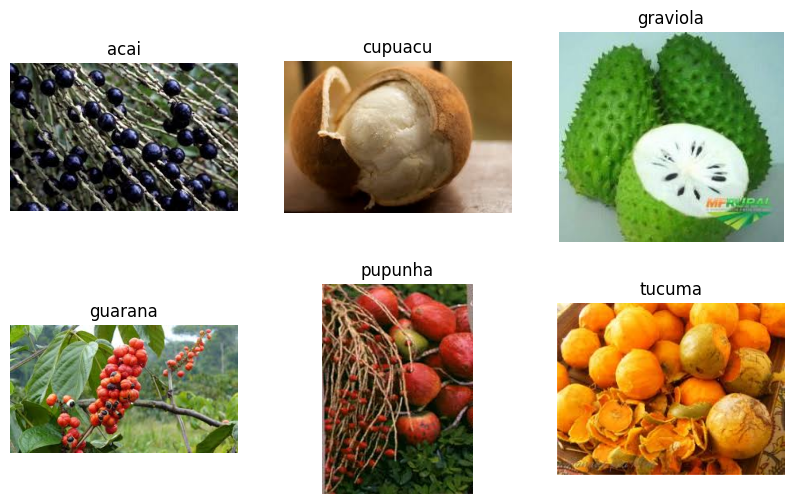

In [8]:
plt.figure(figsize=(10,6))
for i, cls in enumerate(class_names[:6]):
    img_path = os.path.join(train_dir, cls, random.choice(os.listdir(os.path.join(train_dir, cls))))
    img = Image.open(img_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.show()

###Creating train, validation and test dataset

In [9]:
img_size = (224, 224)
batch_size = 32
seed = 123
# Training dataset (80%)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)
# Validation dataset (20%)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)
# Test dataset (unseen data)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


###Dataset Inspection
This block checks if the dataset is loaded correctly by printing shapes and showing some images. Prefetching helps speed up training by loading the next batch while the current one is being processed.

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


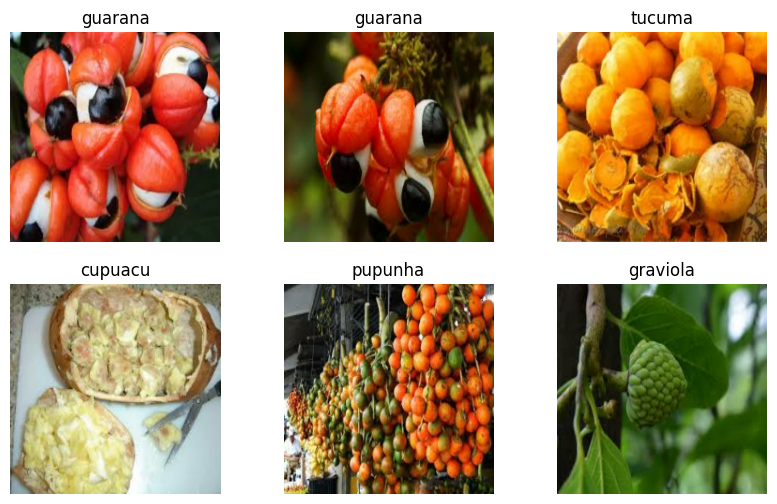

In [10]:
# Check shape of one batch
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

# Show sample images from dataset (not random file system)
plt.figure(figsize=(10,6))
for images, labels in train_ds.take(1):
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

###Data Augmentation and Visualization
This block creates different versions of the same images by flipping, rotating and zooming them. This helps the model see more variations of the data and reduces overfitting.

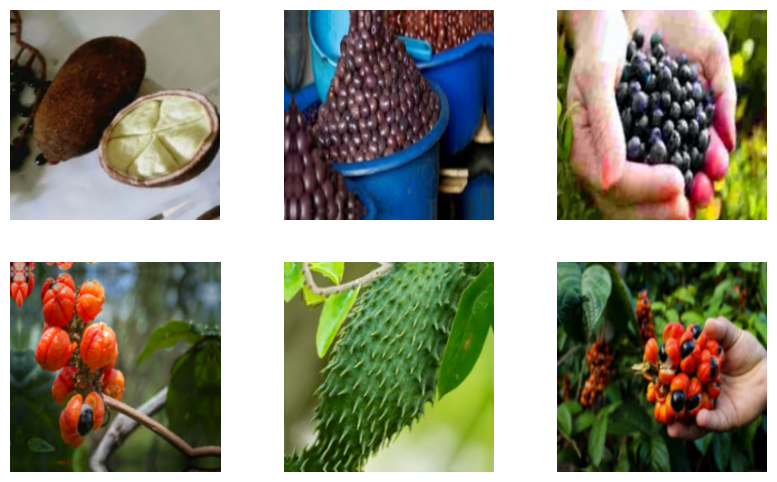

In [11]:
# Data Augmentation Layer
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# Visualize augmented images
plt.figure(figsize=(10,6))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

plt.show()

In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           77

 Total params: 38,820,436 (148.09 MB)

 Trainable params: 12,939,910 (49.36 MB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 25,879,822 (98.72 MB)

###CNN Model Architecture and Training
This block builds a CNN model to classify images. Convolution layers extract features, pooling reduces size, and dense layers make final predictions. Batch normalization and dropout are used to improve performance and reduce overfitting.

In [16]:
num_classes = len(class_names)

model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Block 3
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])
# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Callbacks
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)
earlystop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)
# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, earlystop]
)

#Evaluation
loss, accuracy = model.evaluate(test_ds)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

#Sample predictions
for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    print("\nSample Predictions:")
    print("Predicted:", [class_names[p] for p in predicted_labels[:5]])
    print("Actual:   ", [class_names[l] for l in labels.numpy()[:5]])

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.1528 - loss: 6.5425 - val_accuracy: 0.2778 - val_loss: 1.8124
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2639 - loss: 2.4303 - val_accuracy: 0.1111 - val_loss: 1.8357
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.2917 - loss: 1.8010 - val_accuracy: 0.2222 - val_loss: 1.7802
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.2917 - loss: 1.7192 - val_accuracy: 0.2222 - val_loss: 1.7481
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2083 - loss: 1.6957 - val_accuracy: 0.2222 - val_loss: 1.7341
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.2361 - loss: 1.6682 - val_accuracy: 0.2222 - val_loss: 1.7148
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.2500 - loss: 1.6453 - val_accuracy: 0.2222 - val_loss: 1.6885
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3056 - loss: 1.5787 - val_accuracy: 0.2222 - val_loss: 1.6505
Epoch 9/50
3/3 ━

###Training and Validation Graphs

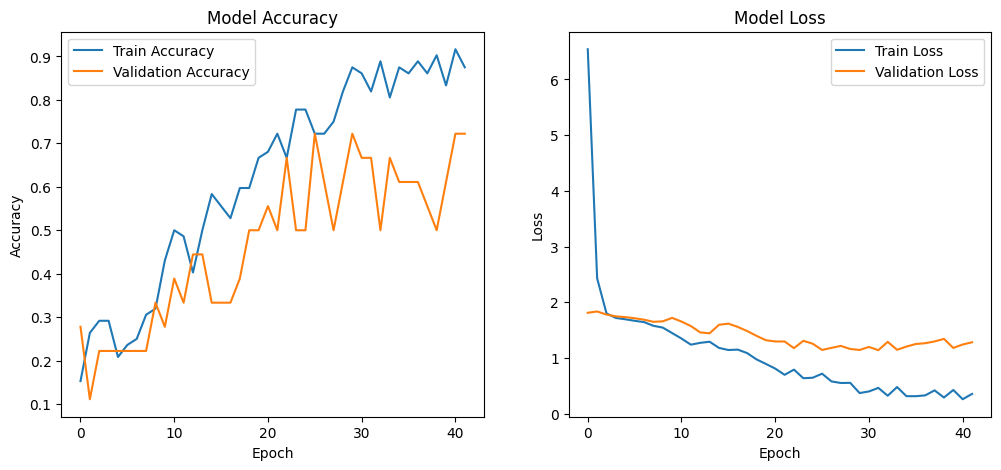

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Classification Report

In [19]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         5
     cupuacu       0.50      0.40      0.44         5
    graviola       0.56      1.00      0.71         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      0.60      0.75         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.73        30
   macro avg       0.76      0.73      0.73        30
weighted avg       0.76      0.73      0.73        30



### Confusion Matrix

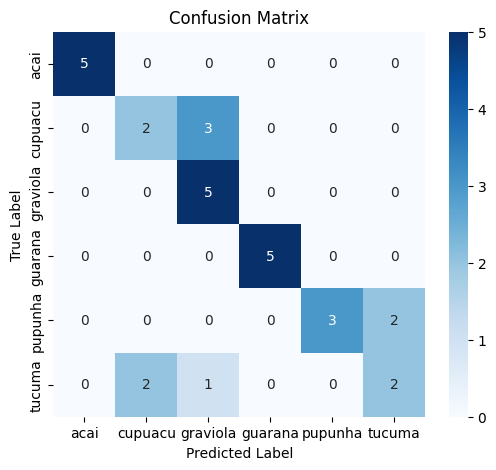

In [20]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

###Transfer Learning using VGG16
This block uses a pre-trained VGG16 model. Instead of training from scratch, it reuses learned features and adds new layers for classification.

In [22]:
from tensorflow.keras.applications import VGG16

# Load pretrained VGG16 (without top layer)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False

# Build new model
model_vgg = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile
model_vgg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,783,174 (56.39 MB)

 Trainable params: 67,462 (263.52 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

###VGG16 Model Training and Evaluation

In [ ]:
checkpoint_vgg = ModelCheckpoint(
    "best_vgg_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

earlystop_vgg = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint_vgg, earlystop_vgg]
)

# Evaluate
loss_vgg, acc_vgg = model_vgg.evaluate(test_ds)

print(f"\nVGG16 Test Accuracy: {acc_vgg:.4f}")

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 63s 19s/step - accuracy: 0.1667 - loss: 2.6700 - val_accuracy: 0.1111 - val_loss: 5.5978
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 89s 18s/step - accuracy: 0.2639 - loss: 2.0227 - val_accuracy: 0.2222 - val_loss: 4.2058
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 73s 18s/step - accuracy: 0.4167 - loss: 1.6726 - val_accuracy: 0.2222 - val_loss: 3.4740
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 89s 19s/step - accuracy: 0.6667 - loss: 0.8305 - val_accuracy: 0.2222 - val_loss: 3.1004
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 86s 24s/step - accuracy: 0.6667 - loss: 0.8942 - val_accuracy: 0.2778 - val_loss: 2.8888
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 72s 18s/step - accuracy: 0.8194 - loss: 0.6821 - val_accuracy: 0.3333 - val_loss: 2.7001
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 18s/step - accuracy: 0.8611 - loss: 0.4892 - val_accuracy: 0.3889 - val_loss: 2.5376
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 93s 23s/step - accuracy: 0.8194 - loss: 0.4307 - val_accuracy: 0.3889 - val_loss: 2.4248


### VGG16 Performance Graphs


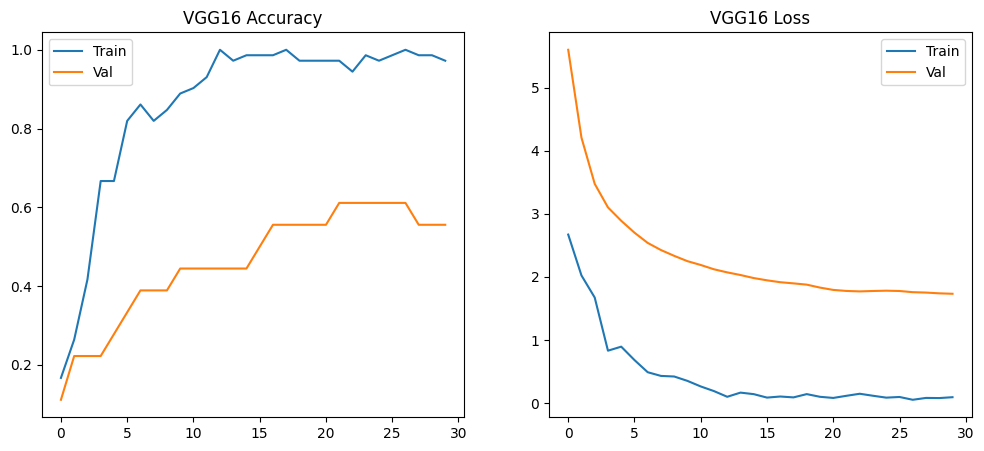

In [24]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_vgg.history['accuracy'], label='Train')
plt.plot(history_vgg.history['val_accuracy'], label='Val')
plt.title("VGG16 Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_vgg.history['loss'], label='Train')
plt.plot(history_vgg.history['val_loss'], label='Val')
plt.title("VGG16 Loss")
plt.legend()

plt.show()